# 02c — LlamaIndex: Indexación y Consulta de Documentos

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/02c-llamaindex.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 2 — Orquestación**. Se recomienda
> haber visto [LangChain](02b-langchain.qmd) primero.

In [1]:
!pip install -q llama-index llama-index-llms-openai-like python-dotenv

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

In [3]:
from llama_index.llms.openai_like import OpenAILike
from llama_index.core.base.embeddings.base import BaseEmbedding
from llama_index.core.base.llms.types import LLMMetadata
from llama_index.core import Settings
from openai import OpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

# Llamus usa una API compatible con OpenAI, pero llama-index necesita adaptadores
# porque valida los modelos contra listas fijas de OpenAI.

class LlamusChatLLM(OpenAILike):
    """OpenAILike con is_chat_model=True para usar /v1/chat/completions."""
    @property
    def metadata(self) -> LLMMetadata:
        meta = super().metadata
        meta.is_chat_model = True
        return meta

class LlamusEmbedding(BaseEmbedding):
    """Embeddings vía API de Llamus (qwen3-embedding)."""
    def __init__(self, model_name: str, api_key: str, api_base: str):
        super().__init__(model_name=model_name)
        self._client = OpenAI(api_key=api_key, base_url=api_base)
        self._model = model_name

    def _get_text_embedding(self, text: str) -> list[float]:
        return self._client.embeddings.create(input=text, model=self._model).data[0].embedding

    def _get_text_embeddings(self, texts: list[str]) -> list[list[float]]:
        return [d.embedding for d in self._client.embeddings.create(input=texts, model=self._model).data]

    def _get_query_embedding(self, query: str) -> list[float]:
        return self._get_text_embedding(query)

    async def _aget_text_embedding(self, text: str) -> list[float]:
        return self._get_text_embedding(text)

    async def _aget_text_embeddings(self, texts: list[str]) -> list[list[float]]:
        return self._get_text_embeddings(texts)

    async def _aget_query_embedding(self, query: str) -> list[float]:
        return self._get_query_embedding(query)

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas siguientes mostrarán este mensaje hasta que configures la clave.")
else:
    Settings.llm = LlamusChatLLM(model="gemma4:e2b-mlx", api_base=LLM_URL, api_key=LLM_KEY, temperature=0)
    Settings.embed_model = LlamusEmbedding("qwen3-embedding:0.6b", api_key=LLM_KEY, api_base=LLM_URL)
    Settings.chunk_size = 512
    Settings.chunk_overlap = 50
    print("✅ LlamaIndex configurado. Las celdas de ejemplo funcionarán correctamente.")

✅ LlamaIndex configurado. Las celdas de ejemplo funcionarán correctamente.

> **Modelo de embeddings multilingüe**
>
> `qwen3-embedding:0.6b` es un modelo de embeddings **multilingüe**
> disponible en Llamus, a diferencia de los modelos ingleses
> (`all-MiniLM-L6-v2`, `e5-small-v2`) usados en el Bloque 1. Esto
> permite que los ejemplos de esta página usen texto en **español** sin
> pérdida de calidad: el tokenizador de Qwen maneja correctamente
> caracteres acentuados y la distribución del espacio semántico está
> calibrada para múltiples idiomas.
>
> Para usar embeddings en español en tu proyecto, `qwen3-embedding:0.6b`
> (o su versión mayor `qwen3-embedding:4b`) son la opción recomendada.

## LlamaIndex

### ¿Qué es LlamaIndex?

LlamaIndex (antes GPT Index) es un **framework de indexación diseñado
específicamente para RAG** (Retrieval-Augmented Generation) y
aplicaciones de pregunta-respuesta sobre tus propios datos.

Mientras LangChain es un framework generalista (cadenas, agentes,
herramientas…), LlamaIndex está especializado en una cosa y la hace muy
bien: **convertir tus documentos en un índice consultable por un LLM**.

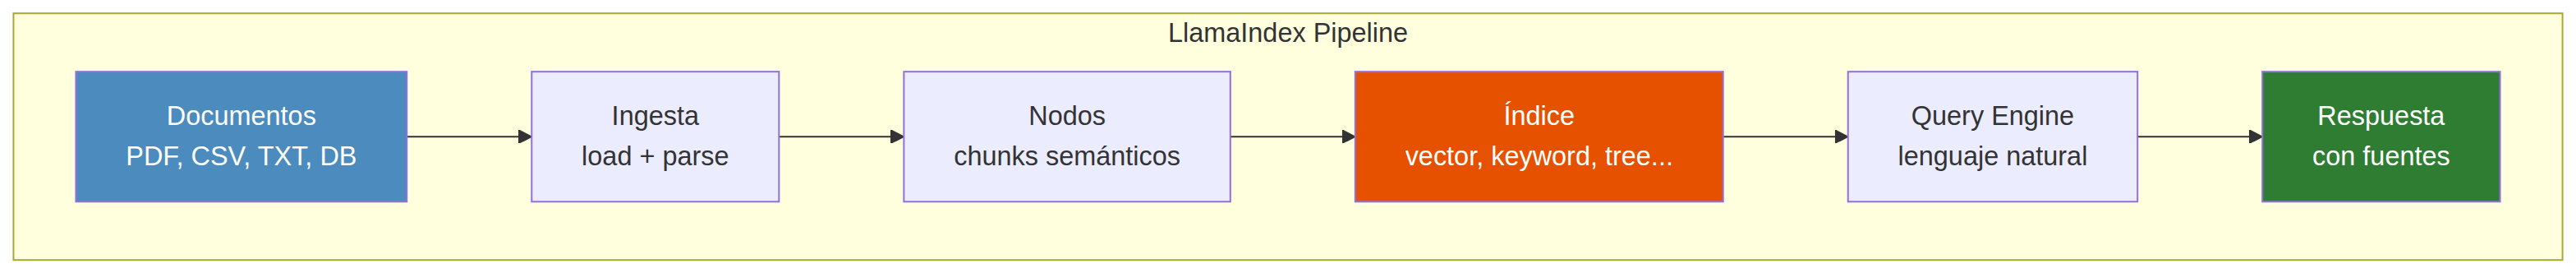

**¿Cuándo elegir LlamaIndex vs LangChain?**

| Criterio | LlamaIndex | LangChain |
|------------------------|------------------------|------------------------|
| **Foco principal** | Indexación y RAG | Orquestación general |
| **Curva de aprendizaje** | Más suave (más opinado) | Más empinada (más flexible) |
| **Carga de documentos** | `SimpleDirectoryReader` carga 20+ formatos | Necesitas cargadores específicos |
| **Índices avanzados** | Árboles, grafos, keywords | Depende de VectorStore |
| **Agentes** | Básico (con herramientas) | Muy potente (ReAct, multi-agente) |

> En muchos proyectos se usan **ambos**: LlamaIndex para indexar y
> recuperar, LangChain para orquestar el agente.

### Primer contacto: indexar y preguntar

In [4]:
from llama_index.core import VectorStoreIndex, Document

# Creamos documentos de ejemplo en memoria (sin necesidad de archivos externos)
textos = [
    "Las ventas de 2025 fueron de 5.6 millones de euros. El producto CloudSync Pro facturó 450k€ en Q1. La región de Madrid aportó el 40% del total.",
    "En 2024 las ventas fueron de 4.8 millones de euros, un crecimiento del 16.7% respecto a 2023. El mejor trimestre fue Q4 con 1.4 millones.",
    "El equipo de Data Science está formado por 12 personas: 4 ingenieros ML, 5 analistas y 3 data engineers. Ana lidera el equipo desde 2023.",
    "La empresa abrió oficina en Barcelona en marzo de 2025 con 8 empleados. La previsión para 2026 es duplicar la plantilla en esta sede.",
]
documentos = [Document(text=t) for t in textos]
print(f"Documentos cargados: {len(documentos)}")

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    indice = VectorStoreIndex.from_documents(documentos)
    query_engine = indice.as_query_engine(similarity_top_k=2)

    respuesta = query_engine.query("¿Cuáles fueron los ingresos totales en 2025?")
    print(f"\nPregunta: ¿Cuáles fueron los ingresos totales en 2025?")
    print(f"Respuesta: {respuesta}")

Documentos cargados: 4

Pregunta: ¿Cuáles fueron los ingresos totales en 2025?
Respuesta: Las ventas de 2025 fueron de 5.6 millones de euros.

### El pipeline de ingesta

La ingesta convierte documentos brutos en nodos indexables:

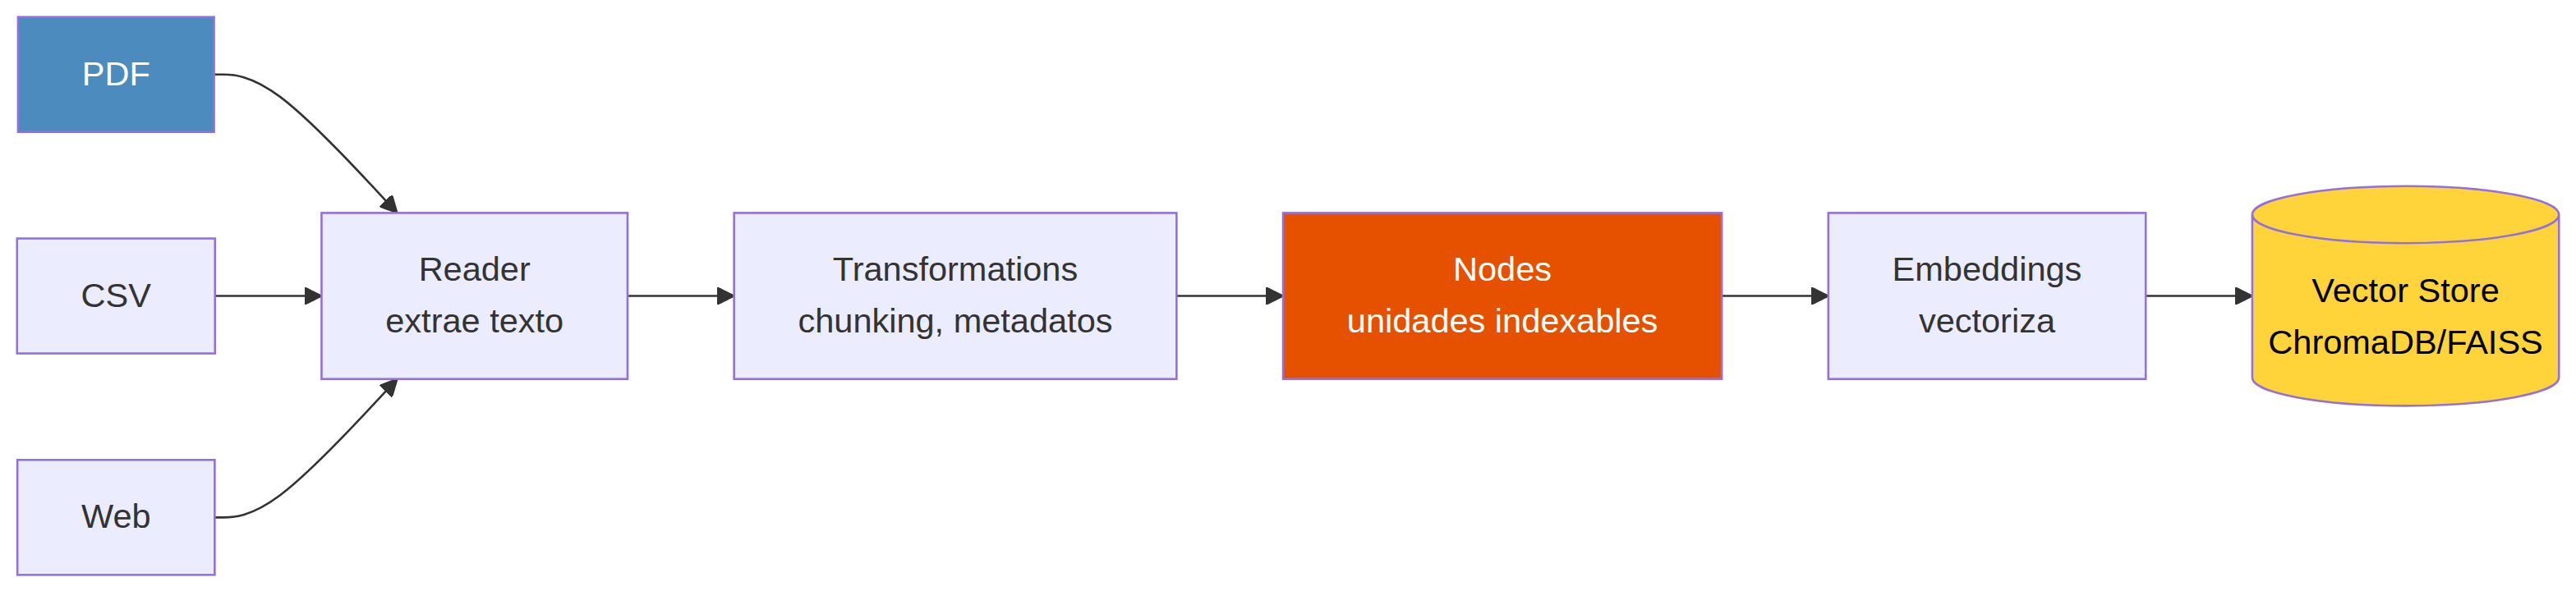

In [5]:
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline

pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=256, chunk_overlap=30),
    ]
)

nodos = pipeline.run(documents=documentos)

print(f"Documentos: {len(documentos)}")
print(f"Nodos generados: {len(nodos)}")
if nodos:
    print(f"Ejemplo de nodo: {nodos[0].text[:150]}...")

Documentos: 4
Nodos generados: 4
Ejemplo de nodo: Las ventas de 2025 fueron de 5.6 millones de euros. El producto CloudSync Pro facturó 450k€ en Q1. La región de Madrid aportó el 40% del total....

### Tipos de índices

No todos los datos se consultan igual. LlamaIndex ofrece varios tipos de
índices:

| Índice | ¿Cómo funciona? | Mejor para |
|------------------------|------------------------|------------------------|
| **VectorStoreIndex** | Embeddings + búsqueda por similitud | Preguntas semánticas |
| **SummaryIndex** | Resume cada chunk y lo encadena | Preguntas generales sobre TODO el documento |
| **KeywordTableIndex** | Extrae keywords de cada chunk | Preguntas muy específicas |

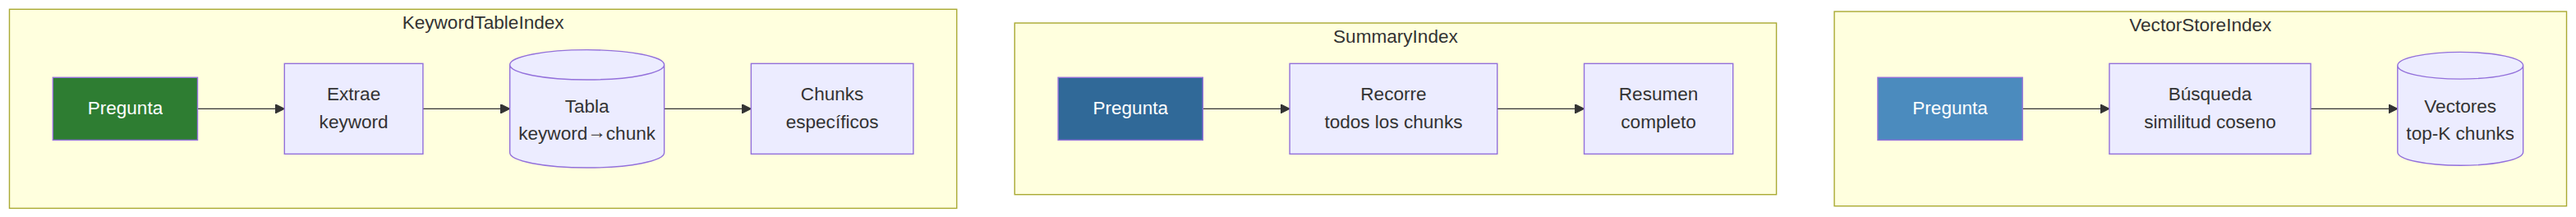

In [6]:
from llama_index.core import VectorStoreIndex, SummaryIndex

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    vector_index = VectorStoreIndex.from_documents(documentos)
    summary_index = SummaryIndex.from_documents(documentos)

    pregunta = "¿Cuánto ha crecido la empresa entre 2024 y 2025?"

    print("=== VectorStoreIndex ===")
    print(vector_index.as_query_engine().query(pregunta))

    print("\n=== SummaryIndex (tree_summarize) ===")
    print(summary_index.as_query_engine(response_mode="tree_summarize").query(pregunta))

=== VectorStoreIndex ===
No es posible determinar cuánto ha crecido la empresa entre 2024 y 2025 con la información proporcionada.

=== SummaryIndex (tree_summarize) ===
Las ventas de 2025 fueron de 5.6 millones de euros, mientras que las ventas de 2024 fueron de 4.8 millones de euros. Esto representa un crecimiento del 16.7% respecto a 2023.

### Query Engines

Un **Query Engine** es el punto final de la API: recibe una pregunta en
lenguaje natural y devuelve una respuesta.

In [7]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    indice = VectorStoreIndex.from_documents(documentos)
    query_engine = indice.as_query_engine(
        similarity_top_k=3,
        response_mode="compact",
        verbose=True,
    )

    respuesta = query_engine.query("¿Quién lidera el equipo de Data Science y cuántas personas tiene?")
    print(f"\nRespuesta: {respuesta}")

    # Inspeccionar fuentes
    print("\n--- Fuentes utilizadas ---")
    for i, nodo in enumerate(respuesta.source_nodes):
        print(f"Fuente {i+1} (score: {nodo.score:.3f}):")
        print(f"  {nodo.text[:120]}...")


Respuesta: La información necesaria para responder esta pregunta no se encuentra en el texto proporcionado.

--- Fuentes utilizadas ---
Fuente 1 (score: 0.819):
  El equipo de Data Science está formado por 12 personas: 4 ingenieros ML, 5 analistas y 3 data engineers. Ana lidera el e...
Fuente 2 (score: 0.283):
  La empresa abrió oficina en Barcelona en marzo de 2025 con 8 empleados. La previsión para 2026 es duplicar la plantilla ...
Fuente 3 (score: 0.162):
  Las ventas de 2025 fueron de 5.6 millones de euros. El producto CloudSync Pro facturó 450k€ en Q1. La región de Madrid a...

### Consultas sobre datos estructurados (SQL)

LlamaIndex también puede traducir lenguaje natural a SQL:

In [8]:
import sqlite3
import tempfile

# Creamos una BD SQLite de ejemplo en memoria
db = sqlite3.connect(":memory:")
db.execute("CREATE TABLE ventas (id INTEGER, producto TEXT, importe REAL, region TEXT)")
db.execute("INSERT INTO ventas VALUES (1, 'CloudSync', 450000, 'Madrid')")
db.execute("INSERT INTO ventas VALUES (2, 'DataViz', 200000, 'Barcelona')")
db.execute("INSERT INTO ventas VALUES (3, 'CloudSync', 320000, 'Madrid')")
db.execute("INSERT INTO ventas VALUES (4, 'AI Toolkit', 180000, 'Norte')")
db.commit()

print("Base de datos creada:")
for row in db.execute("SELECT * FROM ventas"):
    print(f"  {row}")

# Guardar a disco para usar con SQLAlchemy
tmp = tempfile.NamedTemporaryFile(suffix=".db", delete=False)
tmp.close()
bkp = sqlite3.connect(tmp.name)
for line in db.iterdump():
    bkp.execute(line)
bkp.commit()
bkp.close(); db.close()
db_path = tmp.name

if not LLM_KEY:
    print("\n⚠️  Configura LLM_API_KEY en .env para la demo NLSQL.")
else:
    from llama_index.core import SQLDatabase
    from llama_index.core.query_engine import NLSQLTableQueryEngine
    from sqlalchemy import create_engine

    engine = create_engine(f"sqlite:///{db_path}")
    sql_database = SQLDatabase(engine, include_tables=["ventas"])

    query_engine = NLSQLTableQueryEngine(
        sql_database=sql_database,
        llm=Settings.llm,
        tables=["ventas"]
    )

    pregunta = "¿Cuánto ha facturado CloudSync en total?"
    respuesta = query_engine.query(pregunta)

    print(f"\nPregunta: {pregunta}")
    print(f"SQL generado: {respuesta.metadata.get('sql_query', 'no disponible')}")
    print(f"Respuesta: {respuesta}")

import os as _os
try:
    _os.unlink(db_path)
except FileNotFoundError:
    pass

Base de datos creada:
  (1, 'CloudSync', 450000.0, 'Madrid')
  (2, 'DataViz', 200000.0, 'Barcelona')
  (3, 'CloudSync', 320000.0, 'Madrid')
  (4, 'AI Toolkit', 180000.0, 'Norte')

Pregunta: ¿Cuánto ha facturado CloudSync en total?
SQL generado: SELECT SUM(ventas.importe) FROM ventas WHERE ventas.producto = 'CloudSync'
Respuesta: CloudSync ha facturado un total de 770,000.0.

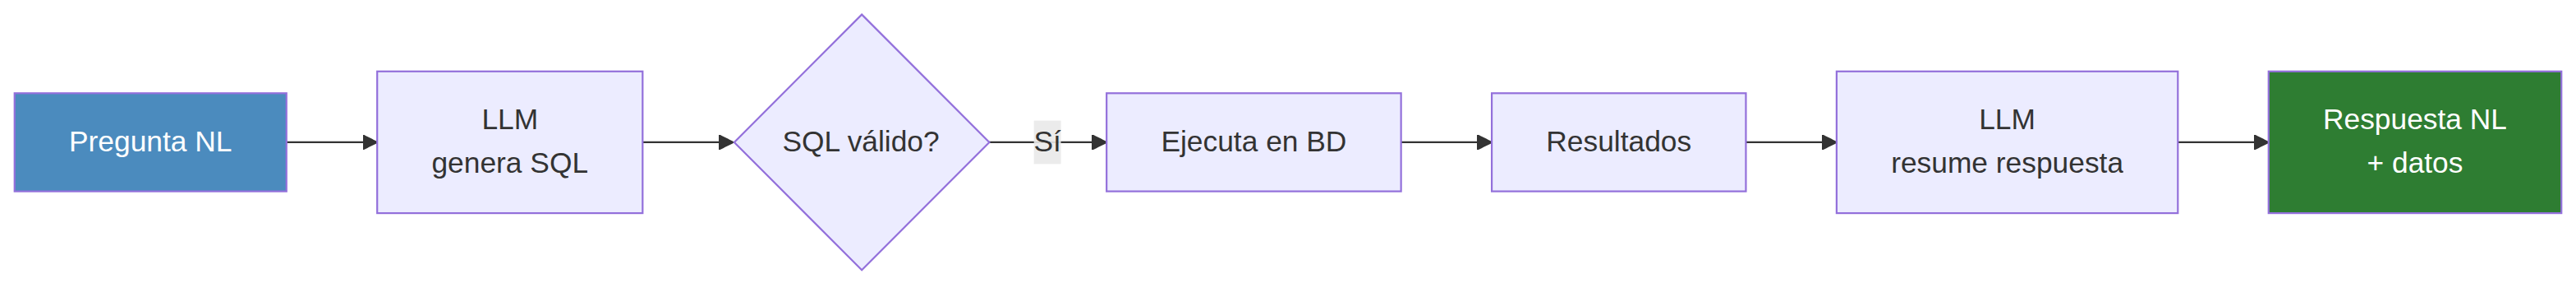

### Chunking estratégico

El tamaño y solapamiento de los chunks afecta drásticamente a la calidad
del RAG:

In [9]:
from llama_index.core.node_parser import SentenceSplitter, TokenTextSplitter

texto_largo = "La inteligencia artificial generativa está transformando el panorama del análisis de datos. " * 30

# Chunking por frases
parser_frases = SentenceSplitter(chunk_size=256, chunk_overlap=30)
nodos_frases = parser_frases.get_nodes_from_documents([Document(text=texto_largo)])

# Chunking por tokens
parser_tokens = TokenTextSplitter(chunk_size=128, chunk_overlap=20)
nodos_tokens = parser_tokens.get_nodes_from_documents([Document(text=texto_largo)])

print(f"Texto original: {len(texto_largo)} caracteres")
print(f"Chunks por frases: {len(nodos_frases)}")
print(f"Chunks por tokens: {len(nodos_tokens)}")

Texto original: 2760 caracteres
Chunks por frases: 3
Chunks por tokens: 5

> **Reglas prácticas de chunking**
>
> - **Chunk pequeño** (128-256 tokens): más preciso, pero puede perder
>   contexto. Bueno para FAQs.
> - **Chunk medio** (512 tokens): buen equilibrio. Funciona para la
>   mayoría de casos.
> - **Chunk grande** (1024+ tokens): mantiene contexto pero es más caro.
> - **Overlap** (10-20% del chunk): evita que una frase quede cortada
>   entre dos chunks.

### Resumen del flujo RAG con LlamaIndex

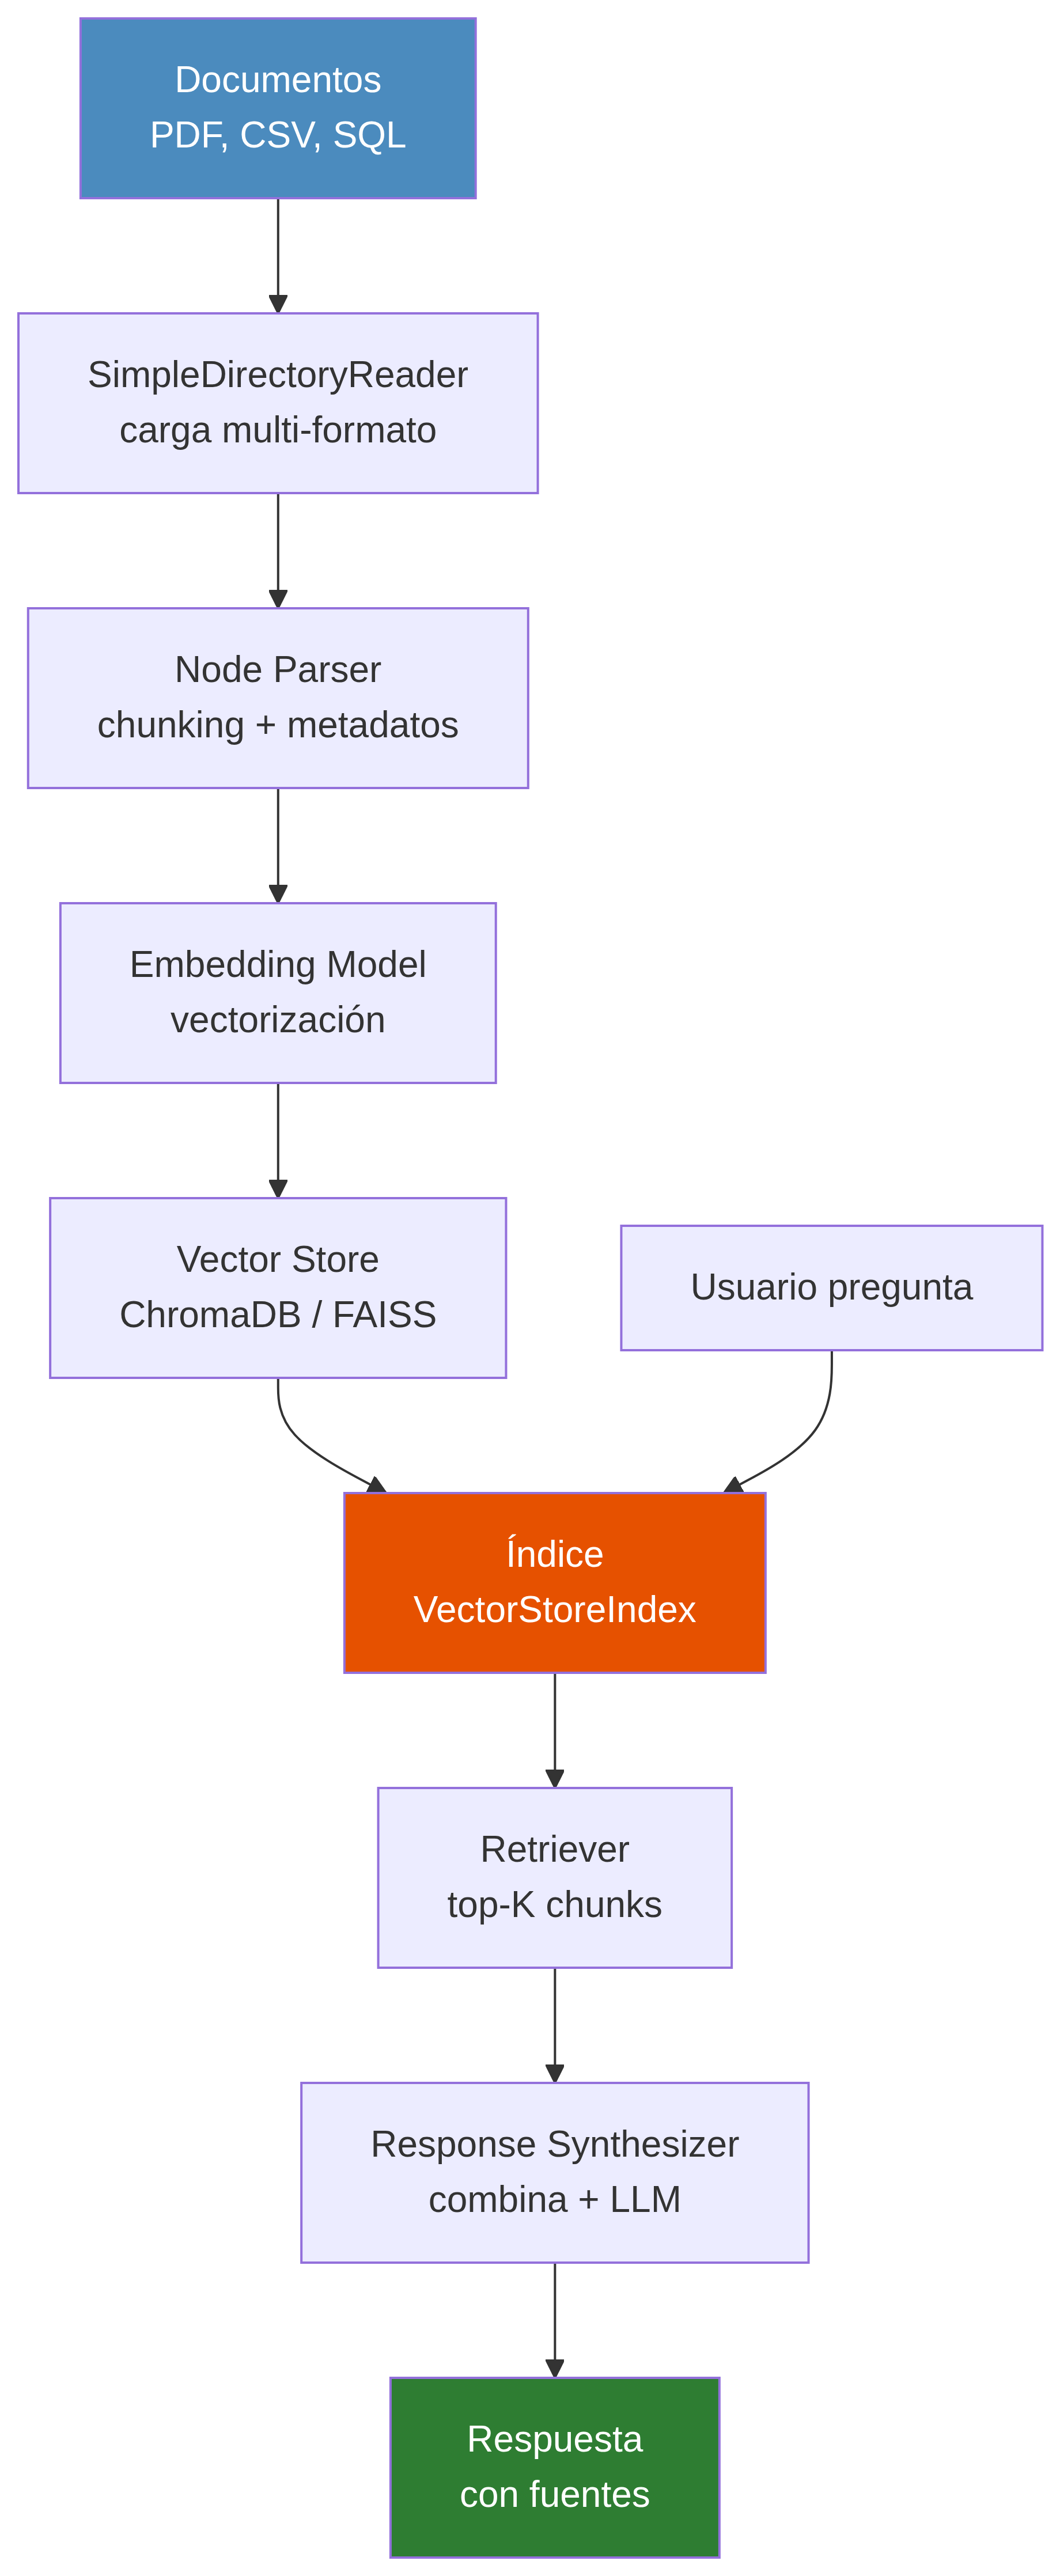

> **Lectura recomendada:** [LlamaIndex
> Documentation](https://docs.llamaindex.ai/en/stable/)